In [3]:
import json
import os

# Class mapping for YOLO format, starting from 0
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "car": 2,
    "truck": 3,
    "bus": 4,
    "train": 5,
    "motorcycle": 6,
    "bicycle": 7,
    "traffic light": 8,
    "traffic sign": 9
}

# Convert the JSON data to YOLO format
def json_to_yolo_format(json_data):
    yolo_annotations = {}
    
    for item in json_data:
        img_name = item['name']
        yolo_labels = []
        
        # Check if 'labels' exists, skip if not
        if 'labels' in item:
            labels = item['labels']
            
            for label in labels:
                category = label['category']
                if category in class_mapping:
                    class_id = class_mapping[category]
                    
                    # Get bounding box coordinates
                    box2d = label.get('box2d', None)
                    if box2d:
                        x1, y1, x2, y2 = box2d['x1'], box2d['y1'], box2d['x2'], box2d['y2']
                        
                        # Convert to YOLO format (center x, center y, width, height)
                        img_width = 1280  # Placeholder: replace with actual image width
                        img_height = 720  # Placeholder: replace with actual image height
                        
                        x_center = (x1 + x2) / 2 / img_width
                        y_center = (y1 + y2) / 2 / img_height
                        width = (x2 - x1) / img_width
                        height = (y2 - y1) / img_height
                        
                        # YOLO format: class_id, x_center, y_center, width, height
                        yolo_label = f"{class_id} {x_center} {y_center} {width} {height}"
                        yolo_labels.append(yolo_label)
        
        # Add to dictionary for saving later
        yolo_annotations[img_name] = yolo_labels

    return yolo_annotations

In [7]:
ip='/home/akshit/codes_and_data/data/bdd100k/roi/labels/det_train.json'
op="/home/akshit/codes_and_data/data/bdd100k/roi/labels/train_labels"
# Load the JSON file
with open(ip, 'r') as f:
    json_data = json.load(f)

# Convert the JSON data to YOLO format
yolo_data = json_to_yolo_format(json_data)

# Create the directory "train_extracted" if it doesn't exist
output_dir = op
os.makedirs(output_dir, exist_ok=True)

# Save each image's labels in separate .txt files
for img_name, labels in yolo_data.items():
    img_base_name = os.path.splitext(img_name)[0]
    txt_filename = os.path.join(output_dir, f"{img_base_name}.txt")
    
    with open(txt_filename, 'w') as txt_file:
        for label in labels:
            txt_file.write(f"{label}\n")

print(f"YOLO annotations saved in '{output_dir}' directory.")


YOLO annotations saved in '/home/akshit/codes_and_data/data/bdd100k/roi/labels/train_labels' directory.


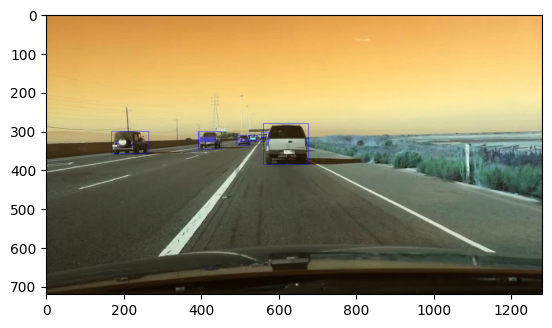

In [2]:
import cv2
import matplotlib.pyplot as plt

image_path = "/home/akshit/codes_and_data/data/bdd100k/roi/images/train/0a0a0b1a-7c39d841.jpg"
label_file = "/home/akshit/codes_and_data/data/bdd100k/roi/labels/train_labels/0a0a0b1a-7c39d841.txt"

img = cv2.imread(image_path)
dh, dw, _ = img.shape

fl = open(label_file, 'r')
data = fl.readlines()
fl.close()

for dt in data:

    # Split string to float
    _, x, y, w, h = map(float, dt.split(' '))

    # Taken from https://github.com/pjreddie/darknet/blob/810d7f797bdb2f021dbe65d2524c2ff6b8ab5c8b/src/image.c#L283-L291
    # via https://stackoverflow.com/questions/44544471/how-to-get-the-coordinates-of-the-bounding-box-in-yolo-object-detection#comment102178409_44592380
    l = int((x - w / 2) * dw)
    r = int((x + w / 2) * dw)
    t = int((y - h / 2) * dh)
    b = int((y + h / 2) * dh)
    
    if l < 0:
        l = 0
    if r > dw - 1:
        r = dw - 1
    if t < 0:
        t = 0
    if b > dh - 1:
        b = dh - 1

    cv2.rectangle(img, (l, t), (r, b), (0, 0, 255), 1)

plt.imshow(img)
plt.show()

In [4]:
ip='/home/akshit/codes_and_data/data/bdd100k/roi/labels/det_val.json'
op="/home/akshit/codes_and_data/data/bdd100k/roi/labels/val_labels"
# Load the JSON file
with open(ip, 'r') as f:
    json_data = json.load(f)

# Convert the JSON data to YOLO format
yolo_data = json_to_yolo_format(json_data)

# Create the directory "train_extracted" if it doesn't exist
output_dir = op
os.makedirs(output_dir, exist_ok=True)

# Save each image's labels in separate .txt files
for img_name, labels in yolo_data.items():
    img_base_name = os.path.splitext(img_name)[0]
    txt_filename = os.path.join(output_dir, f"{img_base_name}.txt")
    
    with open(txt_filename, 'w') as txt_file:
        for label in labels:
            txt_file.write(f"{label}\n")

print(f"YOLO annotations saved in '{output_dir}' directory.")


YOLO annotations saved in '/home/akshit/codes_and_data/data/bdd100k/roi/labels/val_labels' directory.
